# 01 - Baseline CNN Training

Trains the **Baseline CNN** on the original (un-augmented) dataset.

**Split strategy:** The labelled `train.csv` is split 80/20 (train/val). The Kaggle `test/` folder is unlabelled — Section 7 generates the submission file for the leaderboard.

## 1. Setup & Imports

In [2]:
import os, sys, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data

from sklearn.metrics import accuracy_score, f1_score, classification_report
import kagglehub

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

if torch.cuda.is_available():            device = torch.device('cuda')
elif torch.backends.mps.is_available(): device = torch.device('mps')
else:                                    device = torch.device('cpu')
print('Device:', device)

NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
for c in [os.path.join(NOTEBOOK_DIR,'../src'), os.path.join(NOTEBOOK_DIR,'src'),
          '/Applications/Universidade/4ano_2semestre/ACA/projeto2/aml-butterfly-generative-augmentation/src']:
    c = os.path.abspath(c)
    if os.path.isdir(c) and c not in sys.path:
        sys.path.append(c); break

from dataset import ButterflyDataset
from transforms import get_transforms
from models import BaselineCNN
from utils import get_splits, get_class_mapping, GLOBAL_SEED
print('Modules imported!')

/Users/matildecarvalho/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Device: mps
Modules imported!


## 2. Load Dataset & Create 80/20 Split

In [3]:
path = kagglehub.competition_download('aca-tp-2')
train_dir = os.path.join(path, 'train')
test_dir  = os.path.join(path, 'test')   # unlabelled

df = pd.read_csv(os.path.join(path, 'train.csv'))[['filename', 'label']]

train_df, val_df = get_splits(df, seed=GLOBAL_SEED)
class_to_idx, idx_to_class, classes = get_class_mapping(df)
NUM_CLASSES = len(classes)

total = len(df)
print(f'Total      : {total}')
print(f'Train      : {len(train_df)}  ({len(train_df)/total*100:.1f}%)')
print(f'Validation : {len(val_df)}   ({len(val_df)/total*100:.1f}%)')
print(f'Classes    : {NUM_CLASSES}')

Total      : 5199
Train      : 4159  (80.0%)
Validation : 1040   (20.0%)
Classes    : 75


## 3. DataLoaders

In [4]:
BATCH_SIZE = 32
train_transform, val_transform = get_transforms()

train_dataset = ButterflyDataset(df=train_df, img_dir=train_dir, transform=train_transform)
val_dataset   = ButterflyDataset(df=val_df,   img_dir=train_dir, transform=val_transform)

train_loader = data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = data.DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Train batches: 130 | Val batches: 33


## 4. Model, Loss, Optimizer

In [5]:
model = BaselineCNN(num_classes=NUM_CLASSES).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

## 5. Training Loop with Early Stopping

In [5]:
EPOCHS = 150
PATIENCE = 15
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'val_f1':[]}

best_val_f1 = 0.0
epochs_without_improvement = 0
best_model_path = '../outputs/models/baseline_cnn_best.pth'
os.makedirs('../outputs/models', exist_ok=True)

for epoch in range(EPOCHS):
    model.train()
    trn_loss, preds_all, labels_all = 0.0, [], []
    for imgs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out = model(imgs); loss = criterion(out, labels)
        loss.backward(); optimizer.step()
        trn_loss += loss.item() * imgs.size(0)
        preds_all.extend(out.argmax(1).cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    trn_loss /= len(train_dataset)
    trn_acc   = accuracy_score(labels_all, preds_all)

    model.eval()
    val_loss, preds_all, labels_all = 0.0, [], []
    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Val]', leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            out = model(imgs)
            val_loss += criterion(out, labels).item() * imgs.size(0)
            preds_all.extend(out.argmax(1).cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    val_loss /= len(val_dataset)
    val_acc   = accuracy_score(labels_all, preds_all)
    val_f1    = f1_score(labels_all, preds_all, average='weighted')

    history['train_loss'].append(trn_loss)
    history['train_acc'].append(trn_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f'Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {trn_loss:.4f}  Acc: {trn_acc:.4f} '
          f'|| Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}  F1: {val_f1:.4f}')

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        epochs_without_improvement = 0
        torch.save(model.state_dict(), best_model_path)
        print(f' Best model saved (Val F1: {best_val_f1:.4f})')
    else:
        epochs_without_improvement += 1
        print(f'   No improvement for {epochs_without_improvement} epoch(s).')
        if epochs_without_improvement >= PATIENCE:
            print(f'\nEarly stopping triggered after {epoch+1} epochs! Model hasn\'t improved for {PATIENCE} epochs.')
            break

print('\nTraining complete!')

Epoch 1/150 [Train]:   0%|          | 0/130 [00:00<?, ?it/s]

Epoch 1/150 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 01/150 | Train Loss: 4.2184  Acc: 0.0202 || Val Loss: 4.0155  Acc: 0.0308  F1: 0.0029
 Best model saved (Val F1: 0.0029)


Epoch 2/150 [Train]:   0%|          | 0/130 [00:00<?, ?it/s]

Epoch 2/150 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

...

Epoch 149/150 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 149/150 | Train Loss: 0.5557  Acc: 0.8230 || Val Loss: 0.7518  Acc: 0.7952  F1: 0.7970
 Best model saved (Val F1: 0.7970)


Epoch 150/150 [Train]:   0%|          | 0/130 [00:00<?, ?it/s]

Epoch 150/150 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 150/150 | Train Loss: 0.5641  Acc: 0.8211 || Val Loss: 0.9216  Acc: 0.7673  F1: 0.7695
   No improvement for 1 epoch(s).

Training complete!


## 5b. Demo: Training with 80 Epochs / Patience 5

This section trains a **fresh** `BaselineCNN` for **at most 80 epochs** with a stricter early-stopping patience of **5**.  
The purpose is purely **demonstrative** — to let us compare learning curves and the final metric against the 150-epoch run above.  
The model trained here is **not saved** and is **not used** in subsequent notebooks.

[Demo] Epoch 1/80 [Train]:   0%|          | 0/130 [00:00<?, ?it/s]

[Demo] Epoch 1/80 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

[Demo] Epoch 01/80 | Train Loss: 4.2356  Acc: 0.0272 || Val Loss: 4.0417  Acc: 0.0433  F1: 0.0100
   [Demo] Best so far (Val F1: 0.0100)


[Demo] Epoch 2/80 [Train]:   0%|          | 0/130 [00:00<?, ?it/s]

[Demo] Epoch 2/80 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

...

[Demo] Epoch 79/80 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

[Demo] Epoch 79/80 | Train Loss: 0.8949  Acc: 0.7216 || Val Loss: 1.0086  Acc: 0.7038  F1: 0.7024
   [Demo] No improvement for 4 epoch(s).


[Demo] Epoch 80/80 [Train]:   0%|          | 0/130 [00:00<?, ?it/s]

[Demo] Epoch 80/80 [Val]:   0%|          | 0/33 [00:00<?, ?it/s]

[Demo] Epoch 80/80 | Train Loss: 0.9172  Acc: 0.7098 || Val Loss: 0.9105  Acc: 0.7135  F1: 0.7146
   [Demo] No improvement for 5 epoch(s).

[Demo] Early stopping triggered after 80 epochs!

[Demo] Training complete!
[Demo] Best Val F1: 0.7577  (stopped at epoch 80)


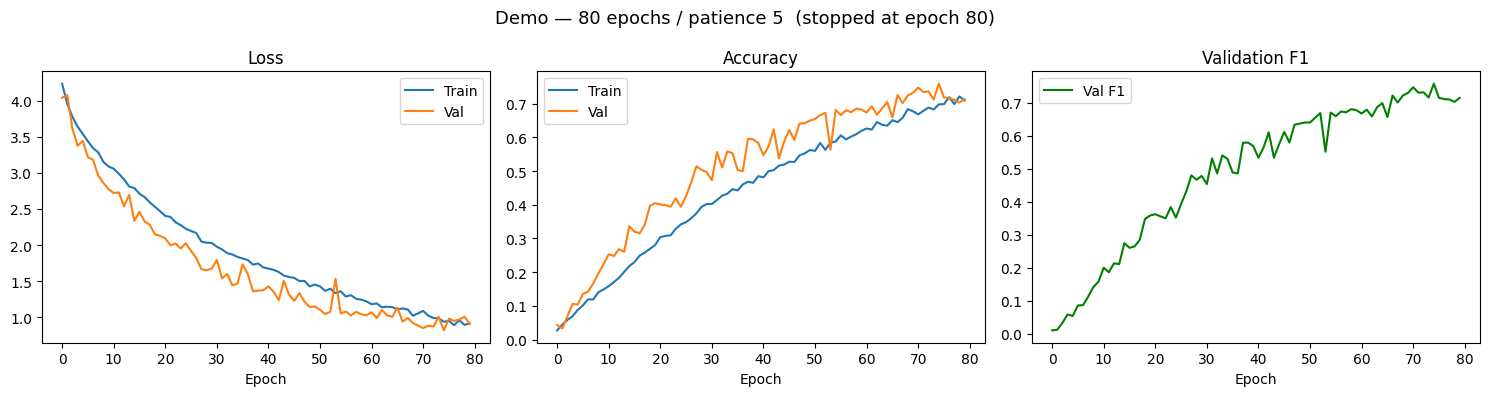

In [6]:
# ── Demo: 80 epochs, patience=5 ── (model NOT saved)
EPOCHS_DEMO   = 80
PATIENCE_DEMO = 5

model_demo     = BaselineCNN(num_classes=NUM_CLASSES).to(device)
optimizer_demo = optim.Adam(model_demo.parameters(), lr=0.001)
history_demo   = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'val_f1':[]}

best_val_f1_demo = 0.0
epochs_without_improvement_demo = 0

for epoch in range(EPOCHS_DEMO):
    model_demo.train()
    trn_loss, preds_all, labels_all = 0.0, [], []
    for imgs, labels in tqdm(train_loader, desc=f'[Demo] Epoch {epoch+1}/{EPOCHS_DEMO} [Train]', leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer_demo.zero_grad()
        out  = model_demo(imgs); loss = criterion(out, labels)
        loss.backward(); optimizer_demo.step()
        trn_loss += loss.item() * imgs.size(0)
        preds_all.extend(out.argmax(1).cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    trn_loss /= len(train_dataset)
    trn_acc   = accuracy_score(labels_all, preds_all)

    model_demo.eval()
    val_loss, preds_all, labels_all = 0.0, [], []
    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f'[Demo] Epoch {epoch+1}/{EPOCHS_DEMO} [Val]', leave=False):
            imgs, labels = imgs.to(device), labels.to(device)
            out = model_demo(imgs)
            val_loss += criterion(out, labels).item() * imgs.size(0)
            preds_all.extend(out.argmax(1).cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    val_loss /= len(val_dataset)
    val_acc   = accuracy_score(labels_all, preds_all)
    val_f1    = f1_score(labels_all, preds_all, average='weighted')

    history_demo['train_loss'].append(trn_loss)
    history_demo['train_acc'].append(trn_acc)
    history_demo['val_loss'].append(val_loss)
    history_demo['val_acc'].append(val_acc)
    history_demo['val_f1'].append(val_f1)

    print(f'[Demo] Epoch {epoch+1:02d}/{EPOCHS_DEMO} | Train Loss: {trn_loss:.4f}  Acc: {trn_acc:.4f} '
          f'|| Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}  F1: {val_f1:.4f}')

    if val_f1 > best_val_f1_demo:
        best_val_f1_demo = val_f1
        epochs_without_improvement_demo = 0
        print(f'   [Demo] Best so far (Val F1: {best_val_f1_demo:.4f})')
    else:
        epochs_without_improvement_demo += 1
        print(f'   [Demo] No improvement for {epochs_without_improvement_demo} epoch(s).')
        if epochs_without_improvement_demo >= PATIENCE_DEMO:
            print(f'\n[Demo] Early stopping triggered after {epoch+1} epochs!')
            break

print('\n[Demo] Training complete!')
print(f'[Demo] Best Val F1: {best_val_f1_demo:.4f}  (stopped at epoch {epoch+1})')

# ── Learning curves (demo) ──────────────────────────────────────────────────
epochs_ran_demo = len(history_demo['train_loss'])
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Demo — 80 epochs / patience 5  (stopped at epoch {epochs_ran_demo})', fontsize=13)

axes[0].plot(history_demo['train_loss'], label='Train')
axes[0].plot(history_demo['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history_demo['train_acc'], label='Train')
axes[1].plot(history_demo['val_acc'],   label='Val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(history_demo['val_f1'], color='green', label='Val F1')
axes[2].set_title('Validation F1'); axes[2].set_xlabel('Epoch'); axes[2].legend()

plt.tight_layout()
plt.show()

del model_demo, optimizer_demo  # free memory — this model is not used further


## 6. Learning Curves

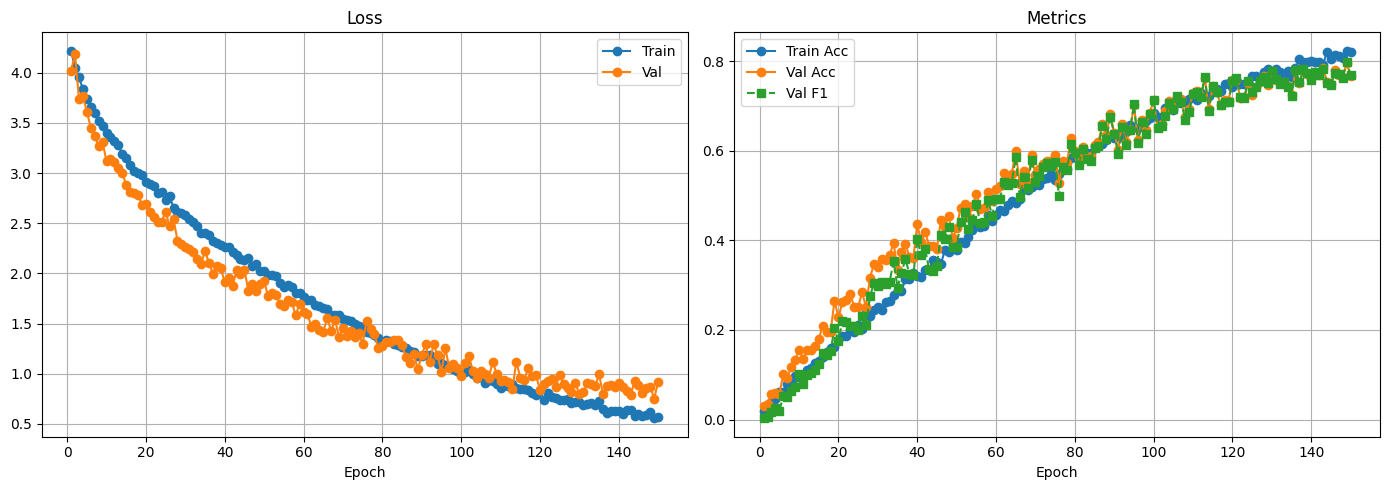

In [6]:
e = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(e, history['train_loss'], label='Train', marker='o')
axes[0].plot(e, history['val_loss'],   label='Val',   marker='o')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(e, history['train_acc'], label='Train Acc', marker='o')
axes[1].plot(e, history['val_acc'],   label='Val Acc',   marker='o')
axes[1].plot(e, history['val_f1'],    label='Val F1',    marker='s', linestyle='--')
axes[1].set_title('Metrics'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True)

os.makedirs('../outputs', exist_ok=True)
plt.tight_layout()
plt.savefig('../outputs/baseline_learning_curves.png', dpi=150)
plt.show()

## 7. Per-class Validation Analysis

In [7]:
# Reload best model and evaluate on validation set
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

preds_all, labels_all = [], []
with torch.no_grad():
    for imgs, labels in tqdm(val_loader, desc='Val Evaluation'):
        preds_all.extend(model(imgs.to(device)).argmax(1).cpu().numpy())
        labels_all.extend(labels.numpy())

val_acc_final = accuracy_score(labels_all, preds_all)
val_f1_final  = f1_score(labels_all, preds_all, average='weighted')

print('=' * 50)
print('BASELINE CNN - BEST MODEL - VALIDATION RESULTS')
print('=' * 50)
print(f'Val Accuracy : {val_acc_final:.4f}')
print(f'Val F1-Score : {val_f1_final:.4f}  (weighted)')
print('=' * 50)

# Save for comparison with augmented models
with open('../outputs/baseline_results.json', 'w') as f:
    json.dump({'model': 'Baseline CNN', 'val_accuracy': val_acc_final,
               'val_f1_weighted': val_f1_final}, f, indent=2)
print('Saved to ../outputs/baseline_results.json')

report_df = pd.DataFrame(classification_report(
    labels_all, preds_all, target_names=train_dataset.classes, output_dict=True
)).T.dropna()

print('\n10 hardest classes:')
display(report_df.sort_values('f1-score').head(10)[['f1-score', 'support']])

Val Evaluation:   0%|          | 0/33 [00:00<?, ?it/s]

BASELINE CNN - BEST MODEL - VALIDATION RESULTS
Val Accuracy : 0.7952
Val F1-Score : 0.7970  (weighted)
Saved to ../outputs/baseline_results.json

10 hardest classes:


,f1-score,support
QUESTION MARK,0.300000,12.0
CLOUDED SULPHUR,0.347826,15.0
GREAT EGGFLY,0.434783,12.0
LARGE MARBLE,0.476190,13.0
TROPICAL LEAFWING,0.516129,13.0
COMMON BANDED AWL,0.518519,14.0
COPPER TAIL,0.533333,15.0
ORANGE OAKLEAF,0.551724,14.0
EASTERN COMA,0.571429,15.0
TWO BARRED FLASHER,0.608696,12.0


## 8. Generate Kaggle Submission File

Runs the best model on the unlabelled `test/` folder and saves `submission.csv` for the Kaggle leaderboard.

In [8]:
import torchvision.transforms as T
from PIL import Image

# List all test images
test_files = sorted(os.listdir(test_dir))
print(f'Test images: {len(test_files)}')

# Same transform as validation (no augmentation)
_, val_transform = get_transforms()

model.eval()
predictions = []

with torch.no_grad():
    for fname in tqdm(test_files, desc='Predicting test set'):
        img_path = os.path.join(test_dir, fname)
        img = Image.open(img_path).convert('RGB')
        img_tensor = val_transform(img).unsqueeze(0).to(device)
        pred_idx = model(img_tensor).argmax(1).item()
        pred_label = idx_to_class[pred_idx]
        predictions.append({'filename': fname, 'label': pred_label})

submission_df = pd.DataFrame(predictions)
submission_df.to_csv('../outputs/baseline_submission.csv', index=False)
print('Submission saved to ../outputs/baseline_submission.csv')
display(submission_df.head())

Test images: 1300


Predicting test set:   0%|          | 0/1300 [00:00<?, ?it/s]

Submission saved to ../outputs/baseline_submission.csv


,filename,label
0,Image_0.jpg,RED ADMIRAL
1,Image_1.jpg,APPOLLO
2,Image_10.jpg,PIPEVINE SWALLOW
3,Image_100.jpg,RED SPOTTED PURPLE
4,Image_1000.jpg,MALACHITE
